12/11/2025 \
Modified from notebooks/data_exploration/greenness_vs_lc_change.ipynb

Did lakes with declining green water color co-occur with woody vegetation expansion? \
Did lakes with increasing aquatic vegetation co-occur with increasing woody or herbaceous vegetation? \
New this notebook: do flow through versus head water lakes behave differently?

Or was hydrologic change the main driver?

Run after notebooks/joins/land-cover-buffer-greenness-above-lc2.py

In [1]:
import geopandas as gpd
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
import seaborn as sns
from tqdm import tqdm
import numpy as np
import pandas as pd
import shapely
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import img_tiles

from land_cover.load import loadGreenness, plot_dir, time_series_features_csv_pth, load_reconstruct_time_series_above_boreal, load_topocat_catchments, load_topocat_pld_lakes
from land_cover.utils import pct_change
from land_cover.plotting import reg_hexplot, reg_scatterplot, add_r2, add_regress, plot_choro_and_hist, boxplots_by_group

%load_ext autoreload
%autoreload 2

In [31]:
# df = pd.read_csv(csv_out_time_series_features_pth)
df = load_reconstruct_time_series_above_boreal()

In [9]:
df.info(max_cols=500, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904782 entries, 0 to 904781
Data columns (total 178 columns):
 #    Column                            Non-Null Count   Dtype  
---   ------                            --------------   -----  
 0    Lake_id_glakes                    904782 non-null  int64  
 1    Area_m2                           904782 non-null  float64
 2    Perim_m2                          904782 non-null  float64
 3    Bare_Sparsely_vegetated_2014      904782 non-null  float64
 4    Deciduous_Forest_2014             904782 non-null  float64
 5    Evergreen_Forest_2014             904782 non-null  float64
 6    Mixed_Forest_2014                 904782 non-null  float64
 7    Herb_2014                         904782 non-null  float64
 8    Shrub_2014                        904782 non-null  float64
 9    Water_2014                        904782 non-null  float64
 10   Wetland_2014                      904782 non-null  float64
 11   Ice_Snow_2014                     904

In [39]:
df.Total_inun_change.describe()
df.Lake_type_tpcat.unique()

array(['Flow Through', 'Headwater', nan, None], dtype=object)

# Bin Plots

In [5]:
yvars = ["sen_slope", "LEV_p13occ_ain", "b2_mean", "NDVI_p1p3_liu"]

In [38]:
# divide into two subdfs based on lake_type_tpcat: Flow Through or Headwater
# Remove Coastal for ease of plotting (ultra minority)
df.query("Lake_type_tpcat != 'Coastal'", inplace=True)


## Plot vars: Total_inun_trend, Trees_trend, Shrub_trend, Wetland_trend, Herb_trend

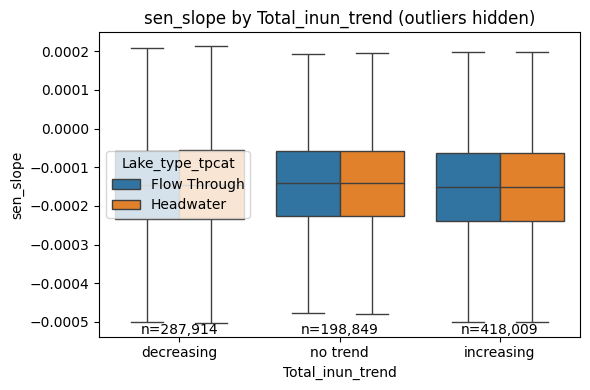

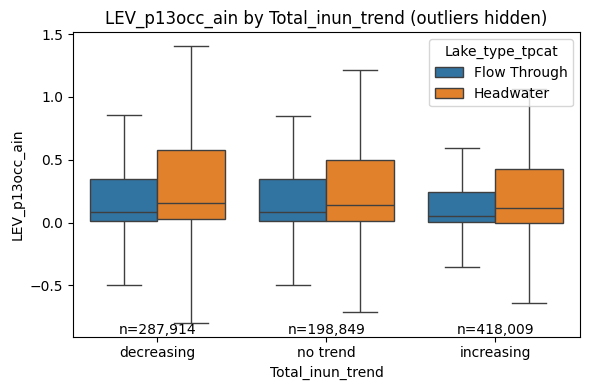

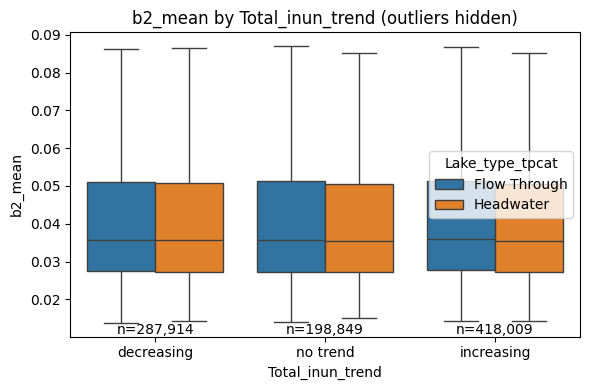

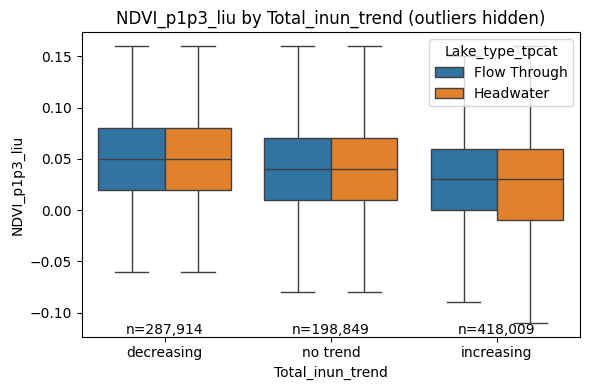

In [40]:
for yvar in yvars:
    boxplots_by_group(df, yvar, group_col="Total_inun_trend", hue="Lake_type_tpcat")

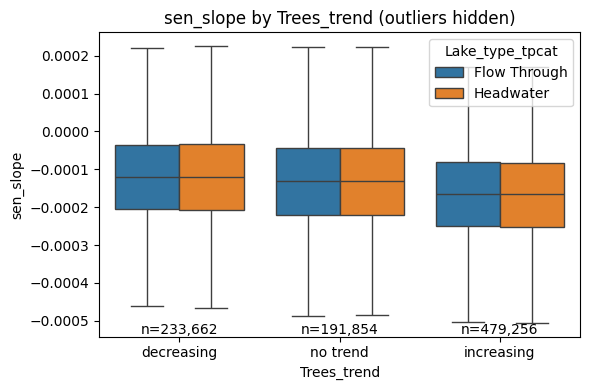

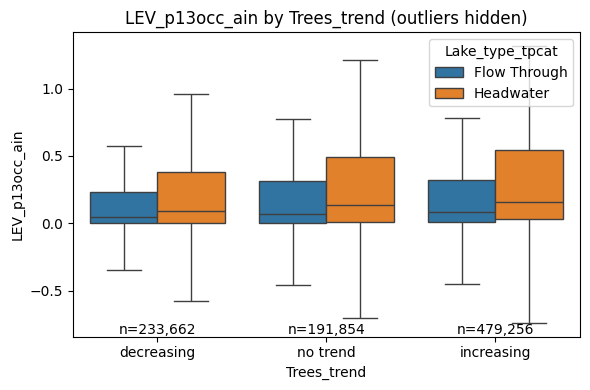

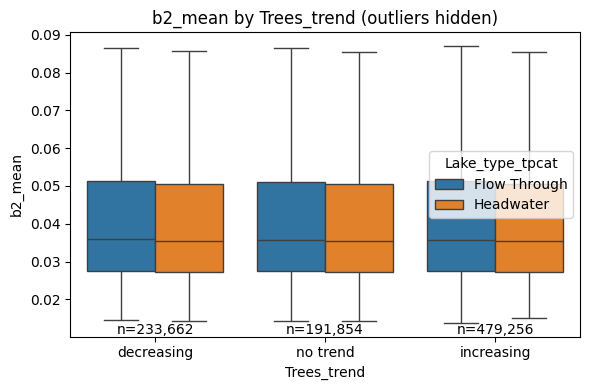

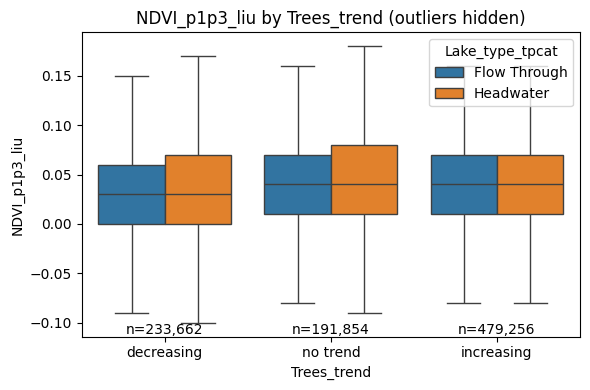

In [41]:
for yvar in yvars:
    boxplots_by_group(df, yvar, group_col="Trees_trend", hue="Lake_type_tpcat")

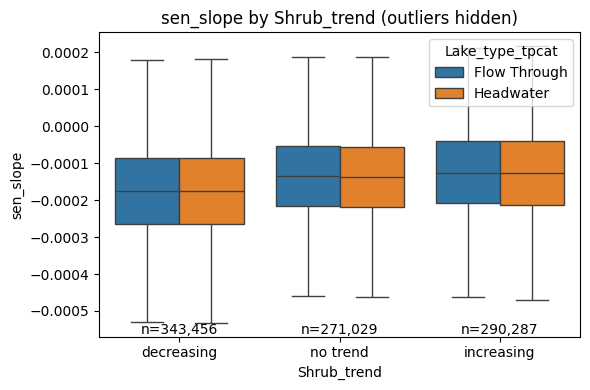

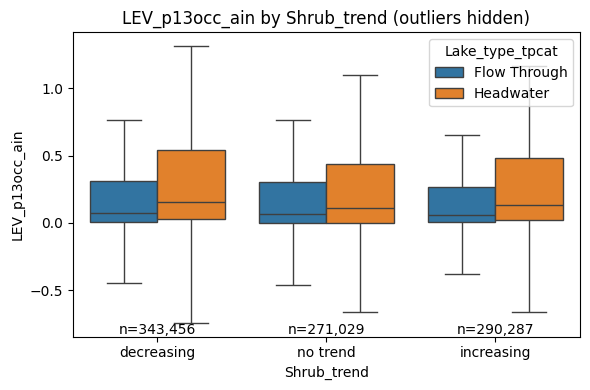

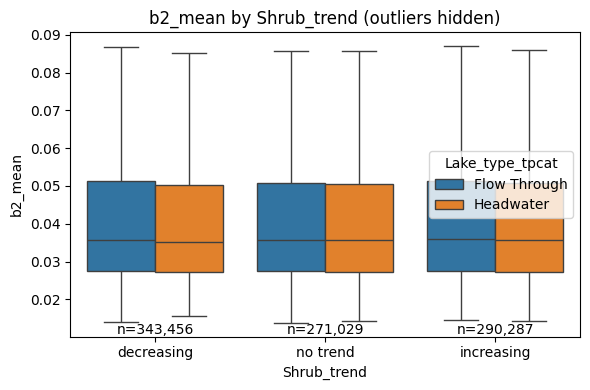

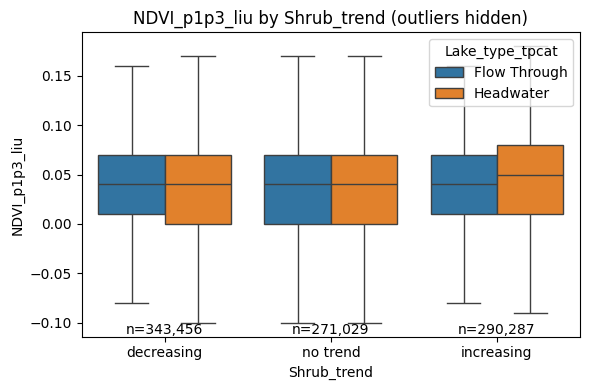

In [47]:
for yvar in yvars:
    boxplots_by_group(df, yvar, group_col="Shrub_trend", hue="Lake_type_tpcat")

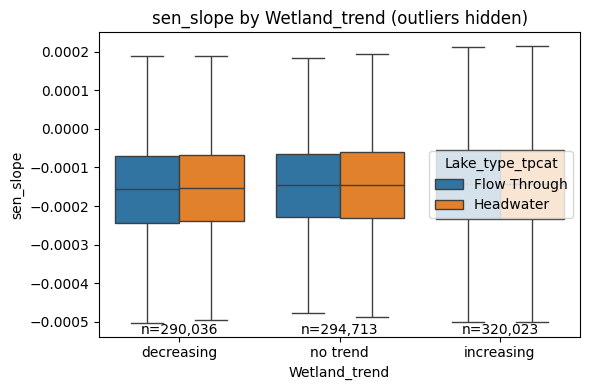

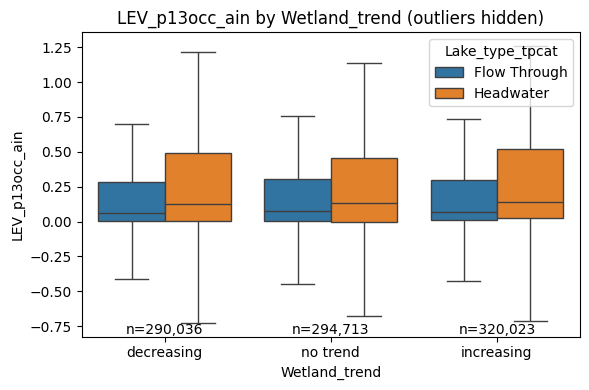

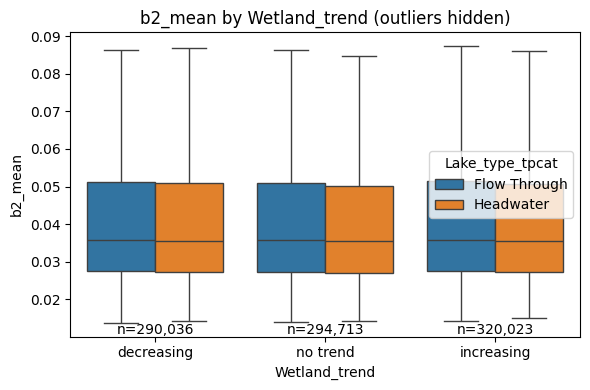

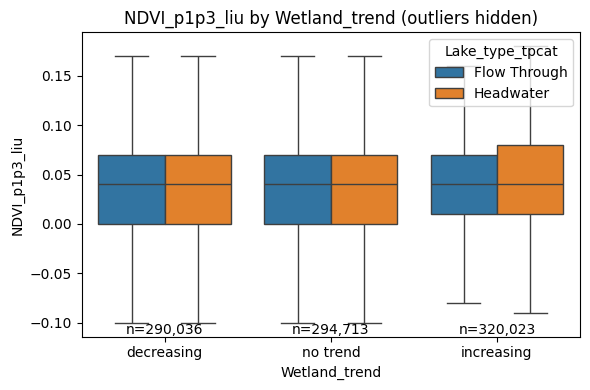

In [43]:
for yvar in yvars:
    boxplots_by_group(df, yvar, group_col="Wetland_trend", hue="Lake_type_tpcat")

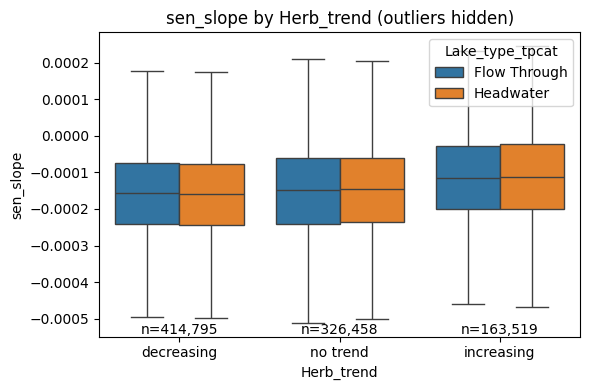

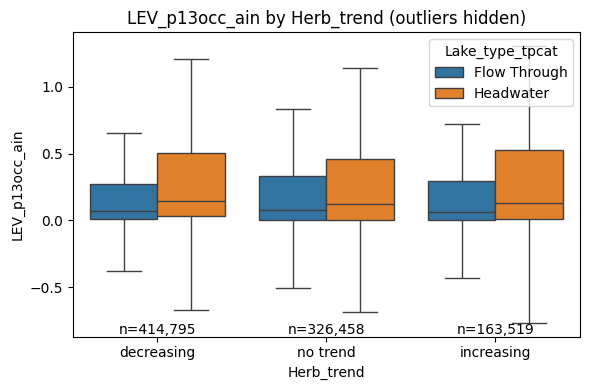

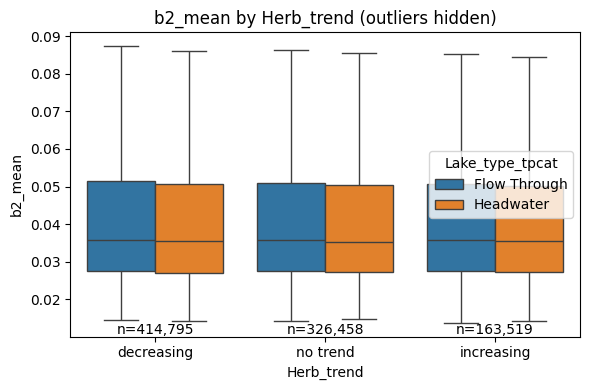

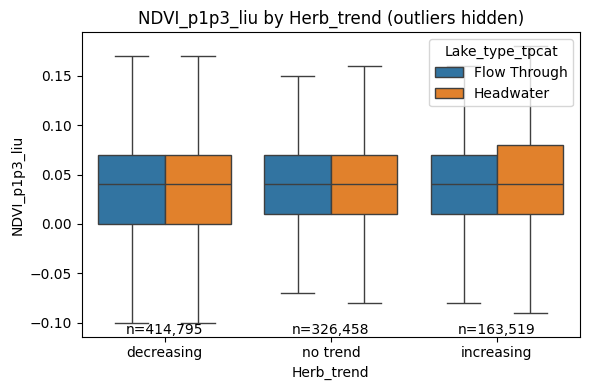

In [45]:
for yvar in yvars:
    boxplots_by_group(df, yvar, group_col="Herb_trend", hue="Lake_type_tpcat")

## Test merrit hydro drainage network variable

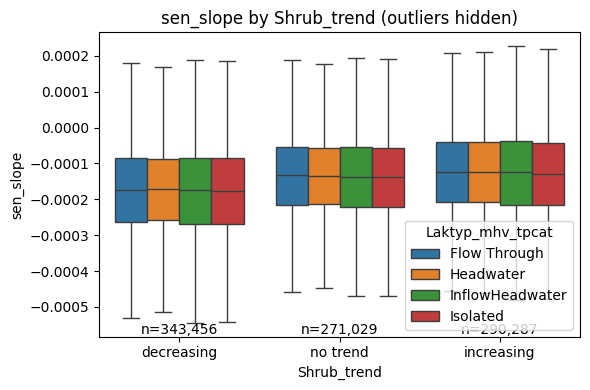

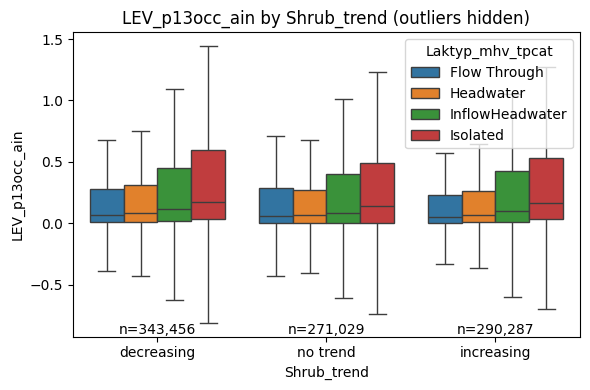

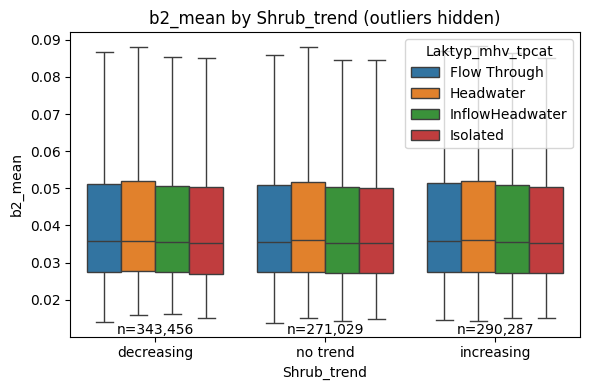

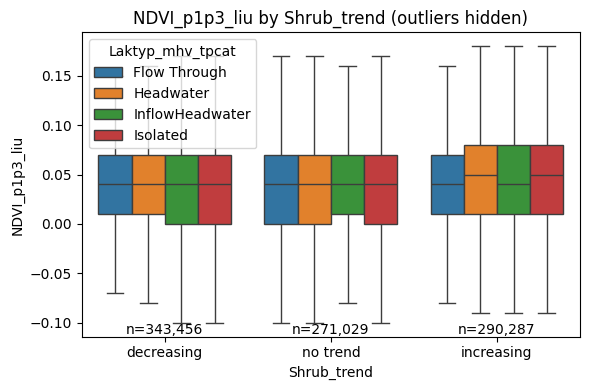

In [48]:
for yvar in yvars:
    boxplots_by_group(df, yvar, group_col="Shrub_trend", hue="Laktyp_mhv_tpcat")

## Group the other way

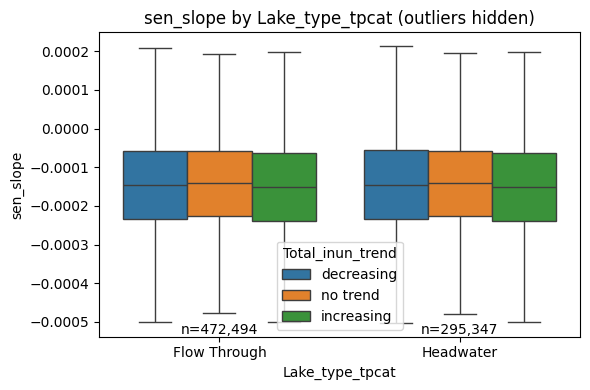

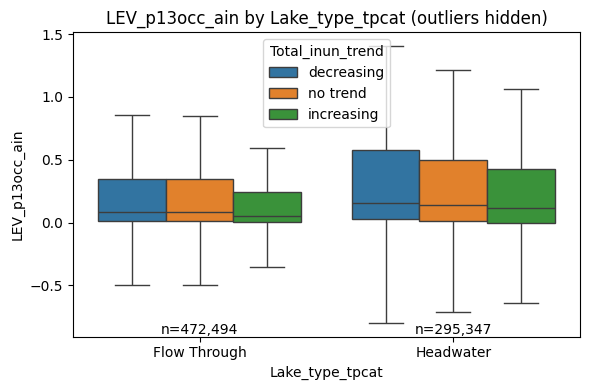

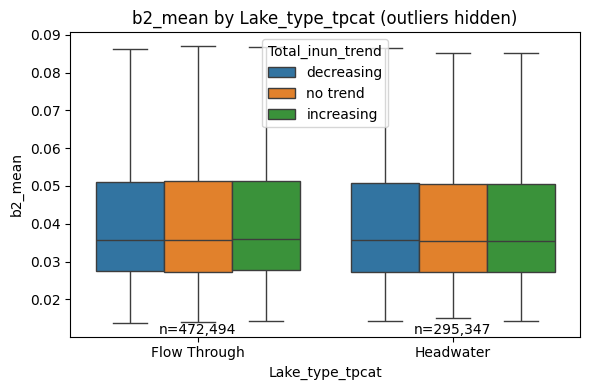

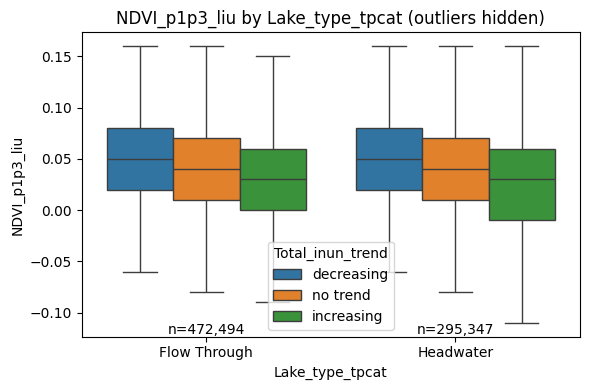

In [78]:
for yvar in yvars:
    boxplots_by_group(
        df,
        yvar,
        group_col="Lake_type_tpcat",
        hue="Total_inun_trend",
        order=["Flow Through", "Headwater"],
        hue_order=["decreasing", "no trend", "increasing"],
    )

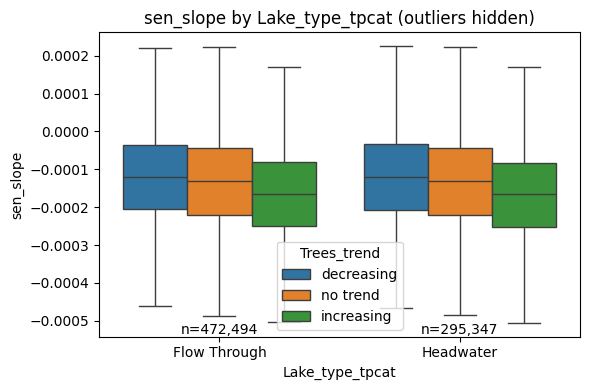

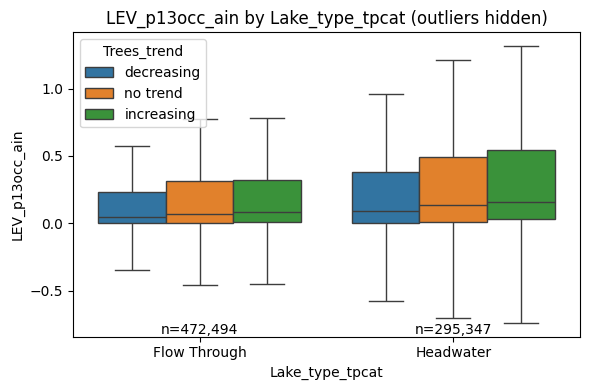

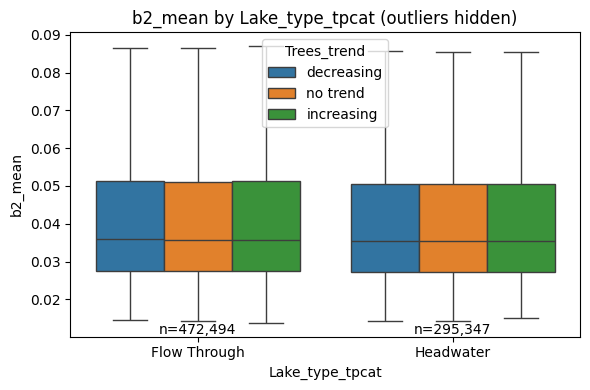

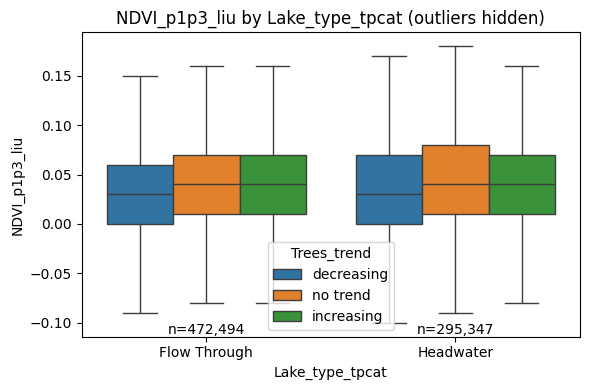

In [77]:
for yvar in yvars:
    boxplots_by_group(
        df,
        yvar,
        group_col="Lake_type_tpcat",
        hue="Trees_trend",
        order=["Flow Through", "Headwater"],
        hue_order=["decreasing", "no trend", "increasing"],
    )

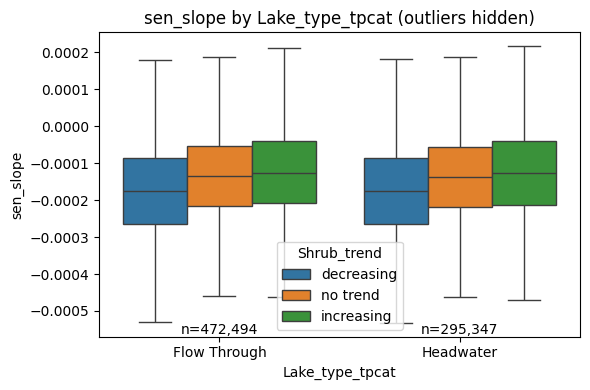

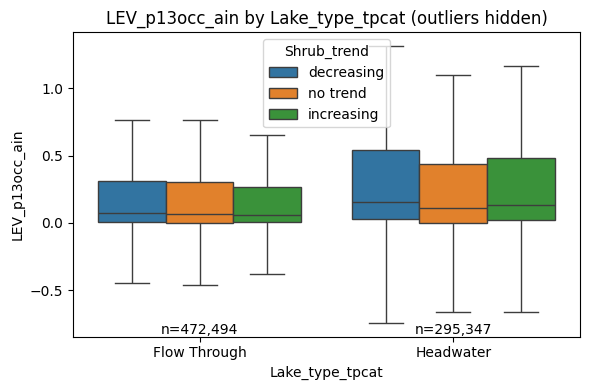

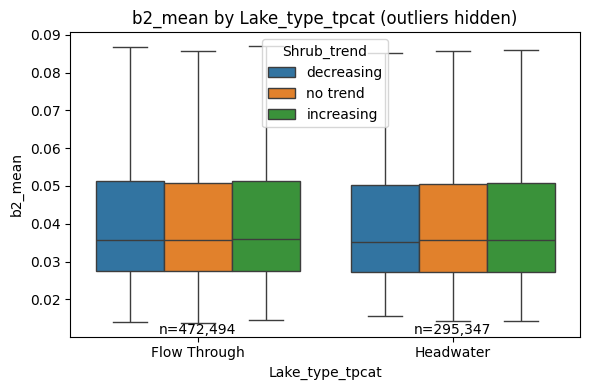

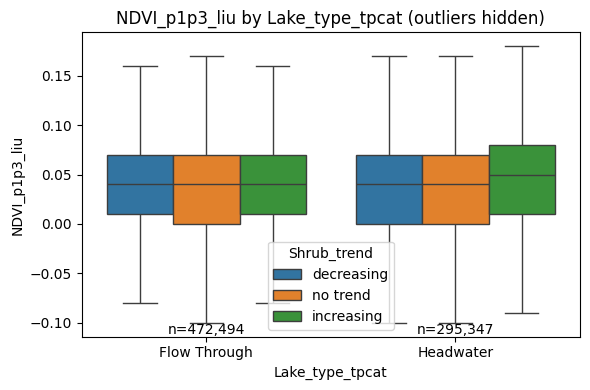

In [76]:
for yvar in yvars:
    boxplots_by_group(
        df,
        yvar,
        group_col="Lake_type_tpcat",
        hue="Shrub_trend",
        order=["Flow Through", "Headwater"],
        hue_order=["decreasing", "no trend", "increasing"],
    )

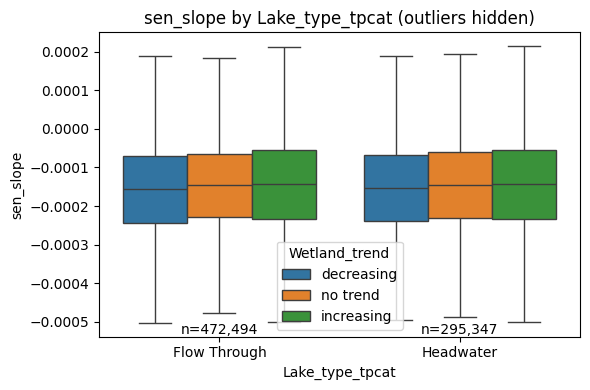

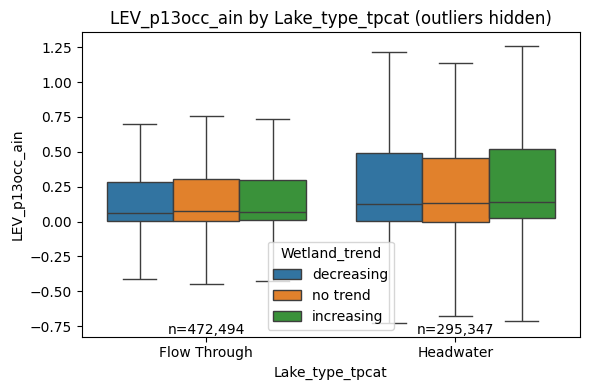

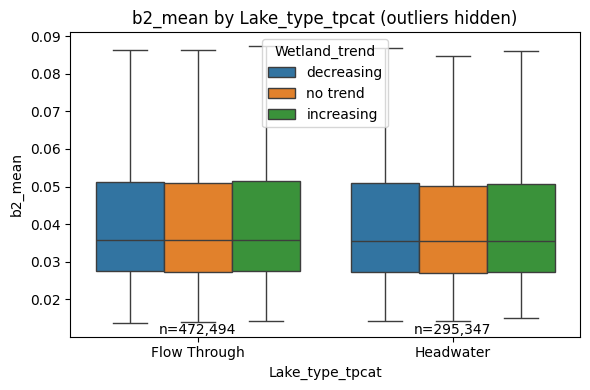

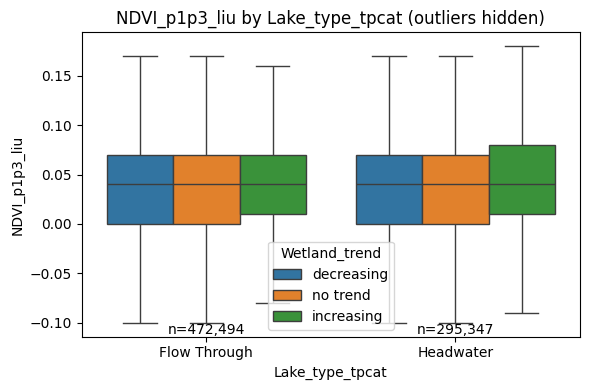

In [75]:
for yvar in yvars:
    boxplots_by_group(
        df,
        yvar,
        group_col="Lake_type_tpcat",
        hue="Wetland_trend",
        order=["Flow Through", "Headwater"],
        hue_order=["decreasing", "no trend", "increasing"],
    )

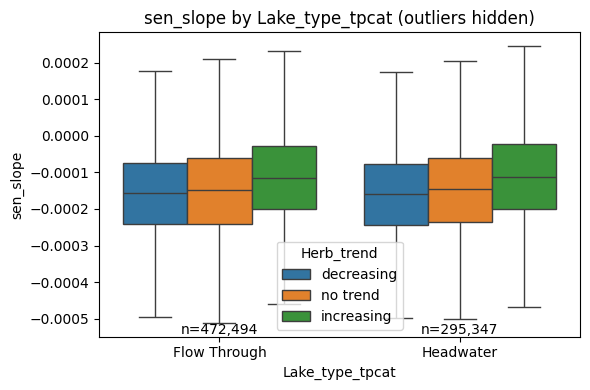

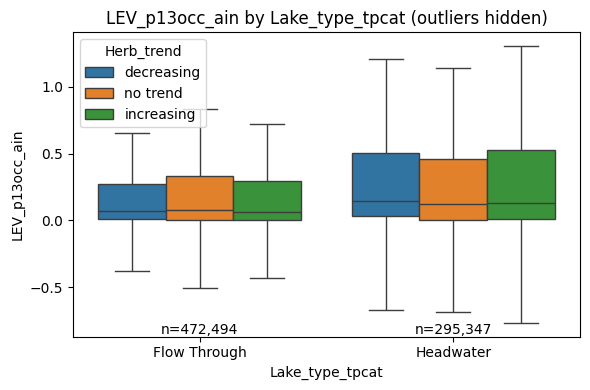

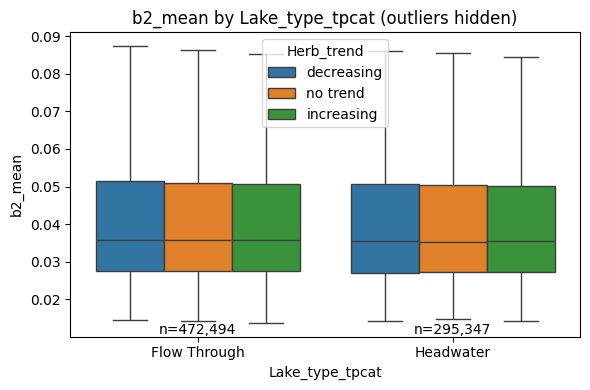

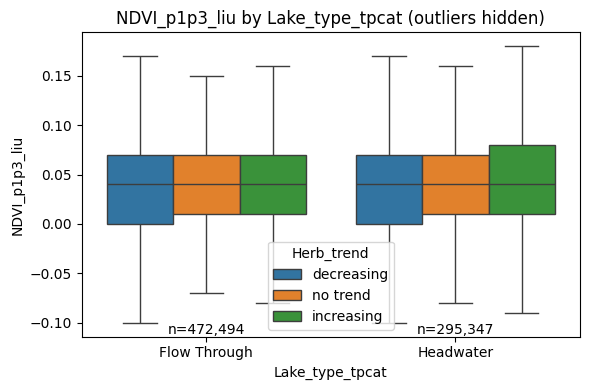

In [74]:
for yvar in yvars:
    boxplots_by_group(
        df,
        yvar,
        group_col="Lake_type_tpcat",
        hue="Herb_trend",
        order=["Flow Through", "Headwater"],
        hue_order=["decreasing", "no trend", "increasing"],
    )

## Test area versus drainage

In [70]:
yvars

['sen_slope', 'LEV_p13occ_ain', 'b2_mean', 'NDVI_p1p3_liu']

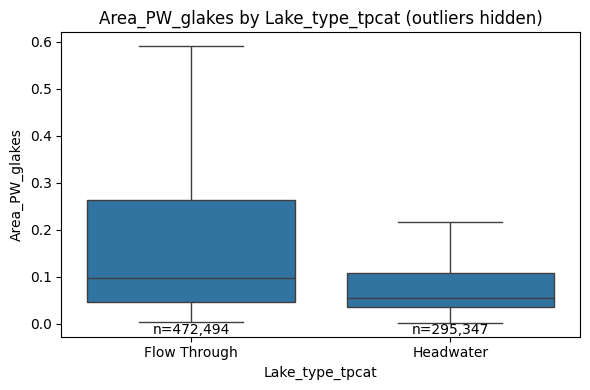

In [73]:
boxplots_by_group(
    df,
    "Area_PW_glakes",
    group_col="Lake_type_tpcat",
    order=["Flow Through", "Headwater"],
)

## ANOVA plots

ANOVA F-statistic: 1209.48, p-value: 0.00e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

decreasing vs. no trend: t-test independent samples, P_val:2.399e-30 t=-1.145e+01
decreasing vs. no trend: t-test independent samples, P_val:2.399e-30 t=-1.145e+01
no trend vs. increasing: t-test independent samples, P_val:1.613e-252 t=-3.403e+01
no trend vs. increasing: t-test independent samples, P_val:1.613e-252 t=-3.403e+01
decreasing vs. increasing: t-test independent samples, P_val:0.000e+00 t=-4.856e+01
decreasing vs. increasing: t-test independent samples, P_val:0.000e+00 t=-4.856e+01


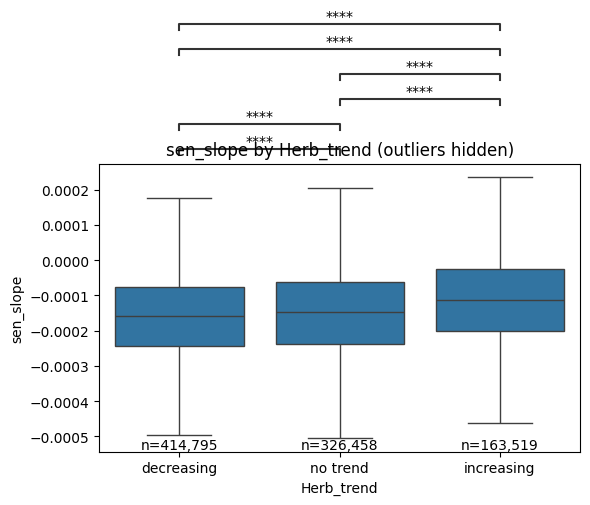

ANOVA F-statistic: 81.14, p-value: 5.88e-36
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

decreasing vs. no trend: t-test independent samples, P_val:1.884e-18 t=-8.765e+00
decreasing vs. no trend: t-test independent samples, P_val:1.884e-18 t=-8.765e+00
no trend vs. increasing: t-test independent samples, P_val:6.945e-07 t=-4.963e+00
no trend vs. increasing: t-test independent samples, P_val:6.945e-07 t=-4.963e+00
decreasing vs. increasing: t-test independent samples, P_val:4.403e-33 t=-1.198e+01
decreasing vs. increasing: t-test independent samples, P_val:4.403e-33 t=-1.198e+01


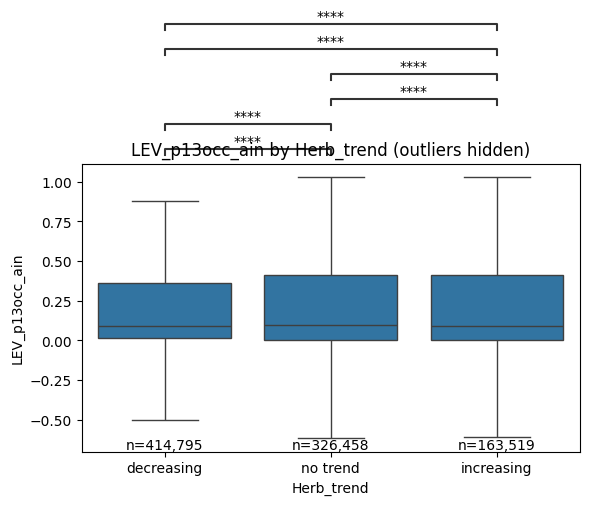

ANOVA F-statistic: 1.59, p-value: 2.03e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

decreasing vs. no trend: t-test independent samples, P_val:1.241e-01 t=1.538e+00
decreasing vs. no trend: t-test independent samples, P_val:1.241e-01 t=1.538e+00
no trend vs. increasing: t-test independent samples, P_val:8.783e-01 t=1.531e-01
no trend vs. increasing: t-test independent samples, P_val:8.783e-01 t=1.531e-01
decreasing vs. increasing: t-test independent samples, P_val:1.664e-01 t=1.384e+00
decreasing vs. increasing: t-test independent samples, P_val:1.664e-01 t=1.384e+00


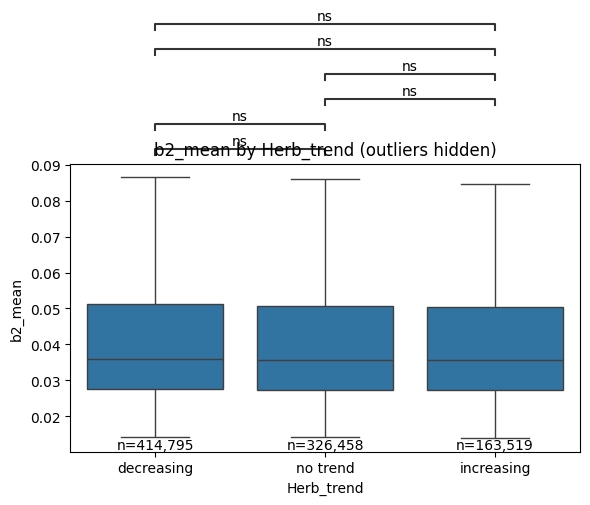

ANOVA F-statistic: 87.61, p-value: 1.03e-38
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

decreasing vs. no trend: t-test independent samples, P_val:4.591e-15 t=-7.840e+00
decreasing vs. no trend: t-test independent samples, P_val:4.591e-15 t=-7.840e+00
no trend vs. increasing: t-test independent samples, P_val:3.621e-12 t=-6.954e+00
no trend vs. increasing: t-test independent samples, P_val:3.621e-12 t=-6.954e+00
decreasing vs. increasing: t-test independent samples, P_val:2.173e-37 t=-1.279e+01
decreasing vs. increasing: t-test independent samples, P_val:2.173e-37 t=-1.279e+01


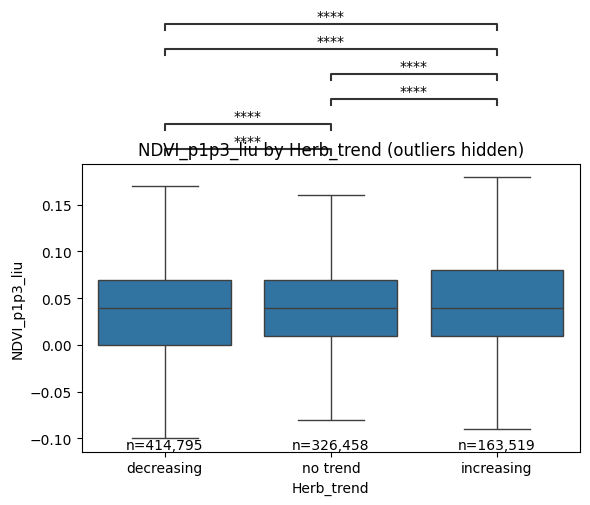

In [64]:
for yvar in yvars:
    boxplots_by_group(
        df,
        yvar,
        group_col="Herb_trend",
        anova=True
    )

ANOVA F-statistic: 0.52, p-value: 4.72e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Flow Through vs. Flow Through: t-test independent samples, P_val:1.000e+00 t=0.000e+00
Headwater vs. Headwater: t-test independent samples, P_val:1.000e+00 t=0.000e+00
Flow Through vs. Headwater: t-test independent samples, P_val:4.724e-01 t=-7.185e-01
Flow Through vs. Headwater: t-test independent samples, P_val:4.724e-01 t=-7.185e-01


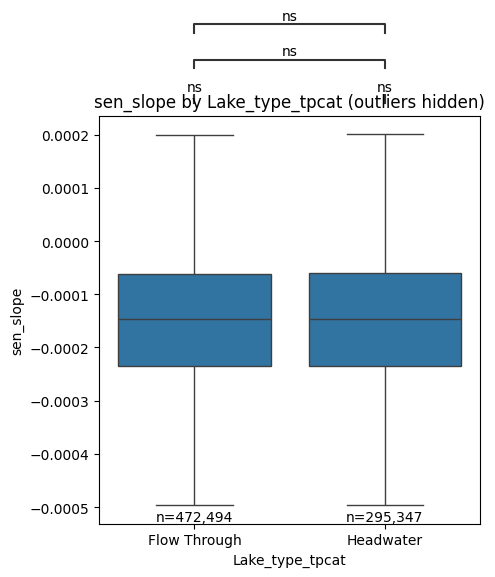

ANOVA F-statistic: 328.92, p-value: 1.81e-73
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Flow Through vs. Flow Through: t-test independent samples, P_val:1.000e+00 t=0.000e+00
Headwater vs. Headwater: t-test independent samples, P_val:1.000e+00 t=0.000e+00
Flow Through vs. Headwater: t-test independent samples, P_val:1.810e-73 t=-1.814e+01
Flow Through vs. Headwater: t-test independent samples, P_val:1.810e-73 t=-1.814e+01


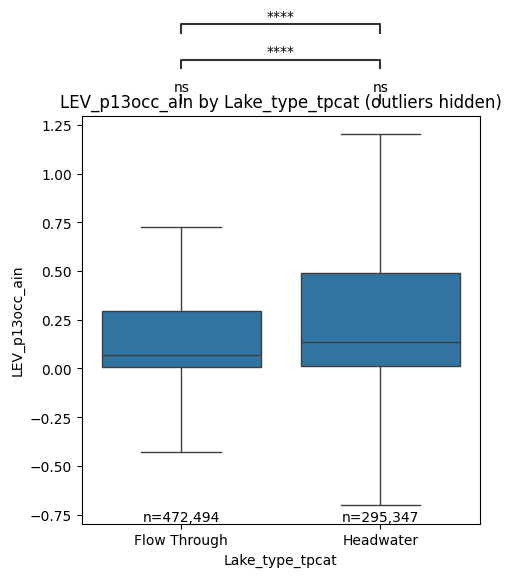

ANOVA F-statistic: 26.32, p-value: 2.89e-07
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Flow Through vs. Flow Through: t-test independent samples, P_val:1.000e+00 t=0.000e+00
Headwater vs. Headwater: t-test independent samples, P_val:1.000e+00 t=0.000e+00
Flow Through vs. Headwater: t-test independent samples, P_val:2.889e-07 t=5.131e+00
Flow Through vs. Headwater: t-test independent samples, P_val:2.889e-07 t=5.131e+00


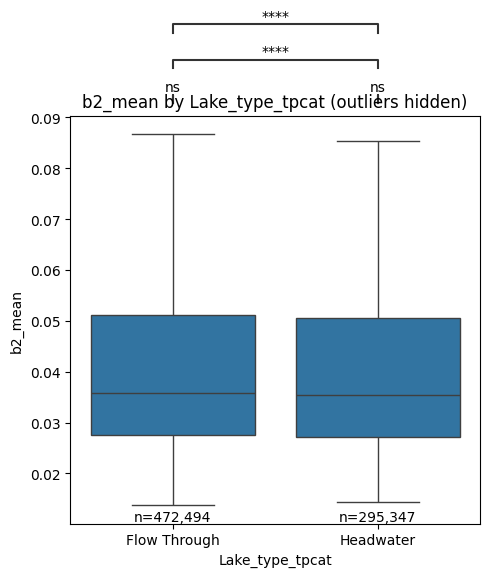

ANOVA F-statistic: 0.00, p-value: 9.91e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Flow Through vs. Flow Through: t-test independent samples, P_val:1.000e+00 t=0.000e+00
Headwater vs. Headwater: t-test independent samples, P_val:1.000e+00 t=0.000e+00
Flow Through vs. Headwater: t-test independent samples, P_val:9.908e-01 t=1.153e-02
Flow Through vs. Headwater: t-test independent samples, P_val:9.908e-01 t=1.153e-02


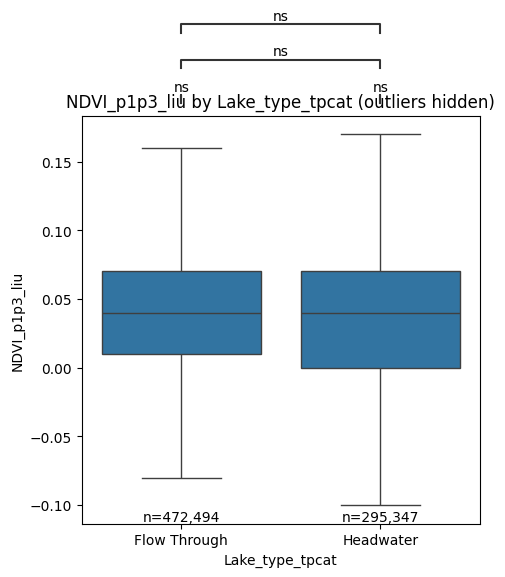

In [69]:
for yvar in yvars:
    boxplots_by_group(
        df,
        yvar,
        group_col="Lake_type_tpcat",
        anova=True,
        order=["Flow Through", "Headwater"],
    )